No responses for  EL013 GT-11-GT-12
No responses for  EL014 Hant-L-1-Hant-L-2


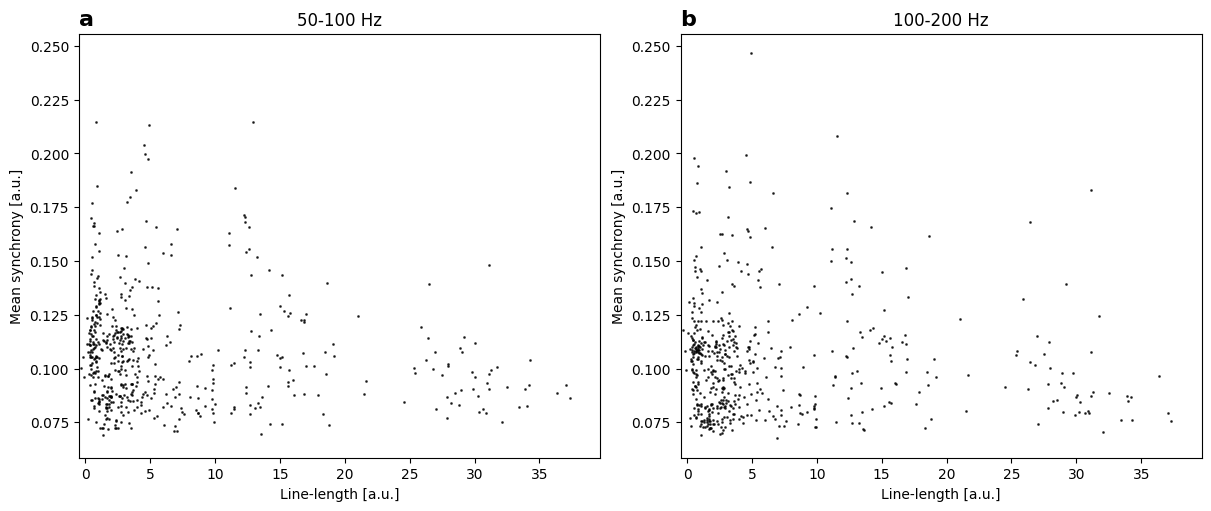

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import json


%load_ext autoreload
%autoreload 2
%aimport connectivity

SYNCHRONY_FILE = "../output/synchrony/peak_synchrony_lf.json"
RESPONSES_FILE = "../output/significant_responses/response_channels_lf.json"
INTENSITIES_FILE = "../output/CR_intensities.json"
SELECTED_INTENSITY = 3

with open(INTENSITIES_FILE, "r") as f:
    intensities_dict = json.load(f)


synchrony_df = pd.read_json(
    SYNCHRONY_FILE
)
responses_df = pd.read_json(
    RESPONSES_FILE
)


PATIENT_IDS = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL013", "EL014", "EL015", "EL016"]
result_rows = []
result_rows_agg = []

for patient_id in PATIENT_IDS:
    intensities = intensities_dict[patient_id]
    pat_responses_df = responses_df[responses_df["patient_id"] == patient_id]
    pat_synchrony_df = synchrony_df[synchrony_df["patient_id"] == patient_id]

    stim_channel_names = pat_responses_df["stim_channel_name"].unique().tolist()
    for stim_channel_name in stim_channel_names:
        stim_responses = pat_responses_df[
            (pat_responses_df["stim_channel_name"] == stim_channel_name) &
            (pat_responses_df["is_significant"] == True)
        ]
        if len(stim_responses) == 0:
            print("No responses for ", patient_id, stim_channel_name)
            continue
        highest_snr_row = stim_responses.loc[stim_responses["snr"].idxmax()]
        response_channel_name = highest_snr_row["response_channel_name"]
        
        id_matrix = np.array(highest_snr_row["id_matrix"]) # shape: (n_intensities, n_reps)
        # for i_int, reps in enumerate(id_matrix[1:]):
        i_int = intensities.index(SELECTED_INTENSITY) # for 3mA

        intensity = intensities[i_int]
        ids = id_matrix[i_int + 1]

        for i_rep, id in enumerate(ids):
            ll_value = highest_snr_row["ll_values"][i_int + 1][i_rep]

            mean_synchrony = pat_synchrony_df.loc[
                (pat_synchrony_df["stim_channel_name"] == stim_channel_name) & 
                (pat_synchrony_df["stim_id"] == id), "50-100_Hz"].squeeze()
            
            mean_synchrony_higher = pat_synchrony_df.loc[
                (pat_synchrony_df["stim_channel_name"] == stim_channel_name) & 
                (pat_synchrony_df["stim_id"] == id), "100-200_Hz"].squeeze()
            
            assert pat_synchrony_df.loc[
                (pat_synchrony_df["stim_channel_name"] == stim_channel_name) & 
                (pat_synchrony_df["stim_id"] == id), "intensity_mA"].squeeze() == intensity, "Intensity mismatch!"

            result_rows.append({
                "patient_id": patient_id,
                "stim_channel_name": stim_channel_name,
                "stim_id": id,
                "response_channel_name": response_channel_name,
                "intensity": intensity,
                "ll_value": ll_value,
                "is_significant": highest_snr_row["is_significant"],
                "snr": highest_snr_row["snr"],
                "mean_synchrony": mean_synchrony,
                "mean_synchrony_higher": mean_synchrony_higher
            })
    result_df = pd.DataFrame(result_rows)

# n_patient * n_stim_channel * n_reps


import numpy as np
import matplotlib.pyplot as plt

def calculate_linear_regression(x, y):
    # Regression y = a*x + b
    a, b = np.polyfit(x, y, 1)

    # Regressionslinie
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = a * x_line + b

    # R²
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot

    return a, b, x_line, y_line, r2





fig = plt.figure(figsize=(12, 5), constrained_layout=True)
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1])

ax_u = fig.add_subplot(gs[0, 0])
x = result_df["ll_value"].values
y = result_df["mean_synchrony"].values
a, b, x_line, y_line, r2 = calculate_linear_regression(x, y)

ax_u.scatter(x, y, alpha=0.7, color="black", s=1)
#ax_u.plot(x_line, y_line, color="red", linewidth=2)

ax_u.set_xlabel("Line-length [a.u.]")
ax_u.set_ylabel("Mean synchrony [a.u.]")
ax_u.set_title(f"50-100 Hz")
ax_u.set_title("a", loc='left', fontsize=16, fontweight='bold')
ax_u.set_xlim(left=-0.5)
#ax_u.annotate(f"n={len(x)}, R² = {r2:.3f}", xy=(0.7, 0.9), xycoords='axes fraction')

ax_l = fig.add_subplot(gs[0, 1], sharey=ax_u, sharex=ax_u)
ax_l.scatter(x, result_df["mean_synchrony_higher"].values, alpha=0.7, color="black", s=1)
a_higher, b_higher, x_line, y_line_higher, r2_higher = calculate_linear_regression(x, result_df["mean_synchrony_higher"].values)
#ax_l.plot(x_line, y_line_higher, color="red", linewidth=2)
ax_l.set_xlabel("Line-length [a.u.]")
ax_l.set_ylabel("Mean synchrony [a.u.]")
ax_l.set_title("b", loc='left', fontsize=16, fontweight='bold')
ax_l.set_title(f"100-200 Hz")
ax_l.set_xlim(left=-0.5)
#ax_l.annotate(f"n={len(x)}, R² = {r2_higher:.3f}", xy=(0.7, 0.9), xycoords='axes fraction')

plt.savefig("../output/figures/sfigure11.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure11.svg", bbox_inches='tight', dpi=300)
plt.show()